# Random-neuron firing enrichment by category

Self-contained notebook for the random-neuron foil to `category_enrichment_figure_styled.ipynb`.
All values are hardcoded from `random_neuron_firing/pythia-*/results.json`, produced by
`random_neuron_subset_firing.py` (3000 random MLP neurons per Pythia size, stratified per layer,
split into 3 disjoint populations of 1000).

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## Data

`SUBSET_COUNTS[run]` is a list of three dicts (one per population), where each dict maps
Pile subset → sum of top-K=20 firings on docs labeled with that subset across the
population's 1000 random neurons.

`CACHE_PRIORS[subset]` = fraction of Pile validation cache tokens belonging to `subset`.

In [2]:
RUNS = ['160m', '410m', '1.4b', '2.8b', '6.9b', '12b']

# Per-population top-20 firing counts. Subsets that did not appear in a given
# population's top-20 examples are absent (treated as 0 below).
SUBSET_COUNTS = {
    '160m': [
        {'ArXiv': 2678, 'Books3': 767, 'DM Mathematics': 724, 'Enron Emails': 20, 'EuroParl': 466, 'FreeLaw': 1576, 'Github': 2048, 'Gutenberg (PG-19)': 146, 'HackerNews': 174, 'NIH ExPorter': 3, 'OpenSubtitles': 556, 'OpenWebText2': 2242, 'Pile-CC': 3470, 'PubMed Abstracts': 3, 'PubMed Central': 3098, 'StackExchange': 724, 'USPTO Backgrounds': 518, 'Ubuntu IRC': 33, 'Wikipedia (en)': 754},
        {'ArXiv': 2233, 'Books3': 828, 'DM Mathematics': 862, 'Enron Emails': 15, 'EuroParl': 467, 'FreeLaw': 1681, 'Github': 2439, 'Gutenberg (PG-19)': 169, 'HackerNews': 200, 'NIH ExPorter': 2, 'OpenSubtitles': 605, 'OpenWebText2': 2280, 'Pile-CC': 3326, 'PubMed Abstracts': 5, 'PubMed Central': 2842, 'StackExchange': 677, 'USPTO Backgrounds': 522, 'Ubuntu IRC': 50, 'Wikipedia (en)': 797},
        {'ArXiv': 2415, 'Books3': 883, 'DM Mathematics': 712, 'Enron Emails': 16, 'EuroParl': 488, 'FreeLaw': 1824, 'Github': 1962, 'Gutenberg (PG-19)': 176, 'HackerNews': 159, 'NIH ExPorter': 4, 'OpenSubtitles': 557, 'OpenWebText2': 2109, 'Pile-CC': 3462, 'PubMed Abstracts': 1, 'PubMed Central': 3101, 'StackExchange': 785, 'USPTO Backgrounds': 522, 'Ubuntu IRC': 42, 'Wikipedia (en)': 782},
    ],
    '410m': [
        {'ArXiv': 2577, 'Books3': 838, 'DM Mathematics': 729, 'Enron Emails': 22, 'EuroParl': 522, 'FreeLaw': 1738, 'Github': 2258, 'Gutenberg (PG-19)': 198, 'HackerNews': 136, 'NIH ExPorter': 4, 'OpenSubtitles': 559, 'OpenWebText2': 2198, 'Pile-CC': 3458, 'PubMed Abstracts': 3, 'PubMed Central': 2802, 'StackExchange': 654, 'USPTO Backgrounds': 442, 'Ubuntu IRC': 54, 'Wikipedia (en)': 808},
        {'ArXiv': 2599, 'Books3': 824, 'DM Mathematics': 733, 'Enron Emails': 24, 'EuroParl': 576, 'FreeLaw': 1773, 'Github': 1936, 'Gutenberg (PG-19)': 174, 'HackerNews': 160, 'NIH ExPorter': 6, 'OpenSubtitles': 557, 'OpenWebText2': 2243, 'Pile-CC': 3481, 'PubMed Abstracts': 8, 'PubMed Central': 2874, 'StackExchange': 624, 'USPTO Backgrounds': 532, 'Ubuntu IRC': 25, 'Wikipedia (en)': 851},
        {'ArXiv': 2382, 'Books3': 735, 'DM Mathematics': 813, 'Enron Emails': 11, 'EuroParl': 544, 'FreeLaw': 1793, 'Github': 2186, 'Gutenberg (PG-19)': 239, 'HackerNews': 174, 'NIH ExPorter': 4, 'OpenSubtitles': 476, 'OpenWebText2': 2223, 'Pile-CC': 3441, 'PubMed Abstracts': 1, 'PubMed Central': 2907, 'StackExchange': 609, 'USPTO Backgrounds': 542, 'Ubuntu IRC': 42, 'Wikipedia (en)': 878},
    ],
    '1.4b': [
        {'ArXiv': 2597, 'Books3': 743, 'DM Mathematics': 1068, 'Enron Emails': 15, 'EuroParl': 577, 'FreeLaw': 1764, 'Github': 2474, 'Gutenberg (PG-19)': 201, 'HackerNews': 164, 'NIH ExPorter': 6, 'OpenSubtitles': 668, 'OpenWebText2': 2015, 'Pile-CC': 3150, 'PubMed Abstracts': 1, 'PubMed Central': 2561, 'StackExchange': 659, 'USPTO Backgrounds': 556, 'Ubuntu IRC': 59, 'Wikipedia (en)': 722},
        {'ArXiv': 2569, 'Books3': 824, 'DM Mathematics': 924, 'Enron Emails': 24, 'EuroParl': 635, 'FreeLaw': 1596, 'Github': 2428, 'Gutenberg (PG-19)': 193, 'HackerNews': 168, 'NIH ExPorter': 4, 'OpenSubtitles': 583, 'OpenWebText2': 2180, 'Pile-CC': 3112, 'PubMed Central': 2680, 'StackExchange': 761, 'USPTO Backgrounds': 481, 'Ubuntu IRC': 56, 'Wikipedia (en)': 782},
        {'ArXiv': 2660, 'Books3': 798, 'DM Mathematics': 1039, 'Enron Emails': 18, 'EuroParl': 566, 'FreeLaw': 1782, 'Github': 2624, 'Gutenberg (PG-19)': 195, 'HackerNews': 169, 'NIH ExPorter': 8, 'OpenSubtitles': 452, 'OpenWebText2': 1988, 'Pile-CC': 3063, 'PubMed Abstracts': 5, 'PubMed Central': 2586, 'StackExchange': 707, 'USPTO Backgrounds': 495, 'Ubuntu IRC': 35, 'Wikipedia (en)': 810},
    ],
    '2.8b': [
        {'ArXiv': 2436, 'Books3': 794, 'DM Mathematics': 1017, 'Enron Emails': 37, 'EuroParl': 558, 'FreeLaw': 1666, 'Github': 2418, 'Gutenberg (PG-19)': 197, 'HackerNews': 180, 'NIH ExPorter': 8, 'OpenSubtitles': 642, 'OpenWebText2': 1992, 'Pile-CC': 3195, 'PubMed Abstracts': 1, 'PubMed Central': 2837, 'StackExchange': 701, 'USPTO Backgrounds': 528, 'Ubuntu IRC': 34, 'Wikipedia (en)': 759},
        {'ArXiv': 2662, 'Books3': 793, 'DM Mathematics': 1080, 'Enron Emails': 22, 'EuroParl': 492, 'FreeLaw': 1740, 'Github': 2420, 'Gutenberg (PG-19)': 234, 'HackerNews': 184, 'NIH ExPorter': 1, 'OpenSubtitles': 679, 'OpenWebText2': 2010, 'Pile-CC': 3124, 'PubMed Abstracts': 1, 'PubMed Central': 2620, 'StackExchange': 681, 'USPTO Backgrounds': 524, 'Ubuntu IRC': 58, 'Wikipedia (en)': 675},
        {'ArXiv': 2653, 'Books3': 733, 'DM Mathematics': 926, 'Enron Emails': 26, 'EuroParl': 569, 'FreeLaw': 1801, 'Github': 2486, 'Gutenberg (PG-19)': 212, 'HackerNews': 159, 'NIH ExPorter': 3, 'OpenSubtitles': 568, 'OpenWebText2': 2044, 'Pile-CC': 3072, 'PubMed Central': 2771, 'StackExchange': 674, 'USPTO Backgrounds': 499, 'Ubuntu IRC': 54, 'Wikipedia (en)': 750},
    ],
    '6.9b': [
        {'ArXiv': 2507, 'Books3': 694, 'DM Mathematics': 1202, 'Enron Emails': 23, 'EuroParl': 390, 'FreeLaw': 1477, 'Github': 2012, 'Gutenberg (PG-19)': 202, 'HackerNews': 164, 'NIH ExPorter': 5, 'OpenSubtitles': 658, 'OpenWebText2': 2125, 'Pile-CC': 3392, 'PubMed Central': 2890, 'StackExchange': 669, 'USPTO Backgrounds': 571, 'Ubuntu IRC': 71, 'Wikipedia (en)': 948},
        {'ArXiv': 2636, 'Books3': 758, 'DM Mathematics': 1060, 'Enron Emails': 29, 'EuroParl': 417, 'FreeLaw': 1287, 'Github': 2041, 'Gutenberg (PG-19)': 254, 'HackerNews': 172, 'NIH ExPorter': 7, 'OpenSubtitles': 791, 'OpenWebText2': 2200, 'Pile-CC': 3451, 'PubMed Abstracts': 3, 'PubMed Central': 2846, 'StackExchange': 706, 'USPTO Backgrounds': 538, 'Ubuntu IRC': 52, 'Wikipedia (en)': 752},
        {'ArXiv': 2537, 'Books3': 774, 'DM Mathematics': 955, 'Enron Emails': 28, 'EuroParl': 546, 'FreeLaw': 1594, 'Github': 2162, 'Gutenberg (PG-19)': 265, 'HackerNews': 161, 'NIH ExPorter': 2, 'OpenSubtitles': 788, 'OpenWebText2': 2151, 'Pile-CC': 3347, 'PubMed Abstracts': 1, 'PubMed Central': 2737, 'StackExchange': 601, 'USPTO Backgrounds': 467, 'Ubuntu IRC': 59, 'Wikipedia (en)': 825},
    ],
    '12b': [
        {'ArXiv': 2522, 'Books3': 644, 'DM Mathematics': 982, 'Enron Emails': 26, 'EuroParl': 416, 'FreeLaw': 1489, 'Github': 2233, 'Gutenberg (PG-19)': 184, 'HackerNews': 194, 'NIH ExPorter': 3, 'OpenSubtitles': 734, 'OpenWebText2': 2164, 'Pile-CC': 3281, 'PubMed Abstracts': 6, 'PubMed Central': 3023, 'StackExchange': 644, 'USPTO Backgrounds': 565, 'Ubuntu IRC': 51, 'Wikipedia (en)': 839},
        {'ArXiv': 2576, 'Books3': 718, 'DM Mathematics': 991, 'Enron Emails': 25, 'EuroParl': 447, 'FreeLaw': 1283, 'Github': 2168, 'Gutenberg (PG-19)': 183, 'HackerNews': 214, 'NIH ExPorter': 4, 'OpenSubtitles': 698, 'OpenWebText2': 2358, 'Pile-CC': 3429, 'PubMed Abstracts': 1, 'PubMed Central': 2760, 'StackExchange': 754, 'USPTO Backgrounds': 499, 'Ubuntu IRC': 42, 'Wikipedia (en)': 850},
        {'ArXiv': 2655, 'Books3': 705, 'DM Mathematics': 905, 'Enron Emails': 29, 'EuroParl': 456, 'FreeLaw': 1419, 'Github': 2198, 'Gutenberg (PG-19)': 202, 'HackerNews': 222, 'NIH ExPorter': 3, 'OpenSubtitles': 772, 'OpenWebText2': 2152, 'Pile-CC': 3348, 'PubMed Central': 2826, 'StackExchange': 690, 'USPTO Backgrounds': 495, 'Ubuntu IRC': 63, 'Wikipedia (en)': 860},
    ],
}

N_NEURONS_PER_POPULATION = 1000
N_POPULATIONS = 3

CACHE_PRIORS = {
    'ArXiv':              0.150036,
    'Books3':             0.035965,
    'DM Mathematics':     0.032211,
    'Enron Emails':       0.000969,
    'EuroParl':           0.010535,
    'FreeLaw':            0.077743,
    'Github':             0.121458,
    'Gutenberg (PG-19)':  0.007266,
    'HackerNews':         0.009809,
    'NIH ExPorter':       0.000242,
    'OpenSubtitles':      0.023613,
    'OpenWebText2':       0.088399,
    'Pile-CC':            0.164931,
    'PubMed Abstracts':   0.000121,
    'PubMed Central':     0.183701,
    'StackExchange':      0.032090,
    'USPTO Backgrounds':  0.024703,
    'Ubuntu IRC':         0.001816,
    'Wikipedia (en)':     0.034391,
}
assert abs(sum(CACHE_PRIORS.values()) - 1.0) < 1e-3, 'priors must sum to ~1'

In [3]:
STACKEXCHANGE_IN = 'formal'  # 'formal' or 'conversational'

OUTPUT_PATH = Path('figures_subset/random_neuron_category_relative_firing_rate_styled.png')

# Six-color palette, cyan -> purple (kept for reference; main plot uses viridis below)
COLORS = ['#06b6d4', '#3b82f6', '#22c55e', '#f59e0b', '#ef4444', '#8b5cf6']

## Category definitions

All 19 Pile subsets in the cache assigned to exactly one of five categories.
The five priors sum to 1.0 (full corpus coverage).

In [4]:
BASE_CATEGORIES = {
    'Code':            ['Github'],
    'Math':            ['DM Mathematics'],
    'Formal/sci':      ['ArXiv', 'PubMed Central', 'PubMed Abstracts',
                        'FreeLaw', 'USPTO Backgrounds', 'NIH ExPorter'],
    'General prose':   ['Pile-CC', 'OpenWebText2', 'Wikipedia (en)',
                        'Books3', 'Gutenberg (PG-19)', 'EuroParl'],
    'Conversational':  ['OpenSubtitles', 'Ubuntu IRC', 'HackerNews', 'Enron Emails'],
}

categories = {k: list(v) for k, v in BASE_CATEGORIES.items()}
if STACKEXCHANGE_IN == 'formal':
    categories['Formal/sci'].append('StackExchange')
elif STACKEXCHANGE_IN == 'conversational':
    categories['Conversational'].append('StackExchange')
else:
    raise ValueError("STACKEXCHANGE_IN must be 'formal' or 'conversational'")

assigned = [s for subs in categories.values() for s in subs]
assert set(assigned) == set(CACHE_PRIORS), 'category assignment must cover all cache subsets'
assert len(assigned) == len(set(assigned)), 'no subset may appear in two categories'

categories

{'Code': ['Github'],
 'Math': ['DM Mathematics'],
 'Formal/sci': ['ArXiv',
  'PubMed Central',
  'PubMed Abstracts',
  'FreeLaw',
  'USPTO Backgrounds',
  'NIH ExPorter',
  'StackExchange'],
 'General prose': ['Pile-CC',
  'OpenWebText2',
  'Wikipedia (en)',
  'Books3',
  'Gutenberg (PG-19)',
  'EuroParl'],
 'Conversational': ['OpenSubtitles',
  'Ubuntu IRC',
  'HackerNews',
  'Enron Emails']}

## Compute per-category enrichment, mean, and 95% CI

For each run, each population $j$, and each category $c$:

$$
p_{c,j} = \frac{\sum_{s \in c} \text{counts}_j[s]}{\sum_s \text{counts}_j[s]}, \qquad
\pi_c = \sum_{s \in c} \pi_s, \qquad
E_{c,j} = p_{c,j} / \pi_c
$$

Then mean $\bar{E}_c$ and 95% CI half-width $t_{0.975,\,n-1}\, s_c / \sqrt{n}$ across the $n=3$ populations.

In [5]:
priors = {c: sum(CACHE_PRIORS[s] for s in subs) for c, subs in categories.items()}

# enrichment_pops[c][run] = list of per-population enrichments
enrichment_pops = {c: {run: [] for run in RUNS} for c in categories}
for run in RUNS:
    for pop_counts in SUBSET_COUNTS[run]:
        total = sum(pop_counts.values())
        for c, subs in categories.items():
            cat_count = sum(pop_counts.get(s, 0) for s in subs)
            enrichment_pops[c][run].append((cat_count / total) / priors[c])

n = N_POPULATIONS
tcrit = stats.t.ppf(0.975, df=n - 1)

enrichment      = {c: [] for c in categories}
enrichment_ci95 = {c: [] for c in categories}
for c in categories:
    for run in RUNS:
        v = np.array(enrichment_pops[c][run])
        enrichment[c].append(float(v.mean()))
        sd = float(v.std(ddof=1))
        enrichment_ci95[c].append(tcrit * sd / np.sqrt(n))

print(f"{'category':<16} {'prior':>6} " + ' '.join(f'{l:>15}' for l in RUNS))
for c in categories:
    cells = [f'{m:.2f}±{h:.2f}' for m, h in zip(enrichment[c], enrichment_ci95[c])]
    print(f"{c:<16} {priors[c]:>6.3f} " + ' '.join(f'{x:>15}' for x in cells))

category          prior            160m            410m            1.4b            2.8b            6.9b             12b
Code              0.121       0.88±0.26       0.88±0.17       1.03±0.10       1.01±0.04       0.85±0.08       0.91±0.03
Math              0.032       1.19±0.32       1.18±0.18       1.57±0.29       1.56±0.30       1.66±0.48       1.49±0.18
Formal/sci        0.469       0.90±0.10       0.88±0.03       0.87±0.02       0.88±0.03       0.86±0.02       0.86±0.05
General prose     0.341       1.15±0.01       1.18±0.02       1.10±0.07       1.08±0.03       1.15±0.03       1.13±0.08
Conversational    0.036       1.12±0.18       1.03±0.13       1.11±0.41       1.22±0.24       1.38±0.25       1.41±0.19


## Sanity check: $\sum_c E_c \pi_c = 1$

Top-K firings sum to 100% of mass. Since the five categories cover all 19 subsets,
the prior-weighted average of mean enrichments must equal 1 for every model size.

In [6]:
for i, label in enumerate(RUNS):
    s = sum(enrichment[c][i] * priors[c] for c in categories)
    print(f"  {label:<5}  sum(E_c * pi_c) = {s:.4f}")

  160m   sum(E_c * pi_c) = 1.0000
  410m   sum(E_c * pi_c) = 1.0000
  1.4b   sum(E_c * pi_c) = 1.0000
  2.8b   sum(E_c * pi_c) = 1.0000
  6.9b   sum(E_c * pi_c) = 1.0000
  12b    sum(E_c * pi_c) = 1.0000


In [7]:
priors

{'Code': 0.121458,
 'Math': 0.032211,
 'Formal/sci': 0.468636,
 'General prose': 0.341487,
 'Conversational': 0.036206999999999996}

In [8]:
0.121458*0.90552564123675135+0.032211*1.2591393209359123+0.468636*0.861258346918859+ 0.341487*1.174059764110103+0.036206999999999996*1.213170565544416

0.9990095499999997

## Plot

In [9]:
enrichment = {'Code': [0.8849423943530549,
  0.8754741007865544,
  1.032730106977995,
  1.0050113345079505,
  0.8528325292144885,
  0.9055256412367513],
 'Math': [1.1890348017757908,
  1.177134105326338,
  1.3683048234040136,
  1.3241654507259426,
  1.4045452381691557,
  1.2591393209359123],
 'Formal/sci': [0.8967158590747047,
  0.8846240294528518,
  0.8705406043638702,
  0.8822412277332514,
  0.8564216150701185,
  0.8612583469188596],
 'General prose': [1.1524108775248643,
  1.1826218860454425,
  1.1007739679694983,
  1.0836430083722075,
  1.1465053330483055,
  1.134059764110103],
 'Conversational': [1.117187284226807,
  1.0311081650877825,
  1.1098222259047514,
  1.2166155715745575,
  1.379107170804909,
  1.413170565544416]}

[0.8849423943530549, 1.1890348017757908, 0.8967158590747047, 1.1524108775248643, 1.117187284226807]
[0.8754741007865544, 1.177134105326338, 0.8846240294528518, 1.1826218860454425, 1.0311081650877825]
[1.032730106977995, 1.3683048234040136, 0.8705406043638702, 1.1007739679694983, 1.1098222259047514]
[1.0050113345079505, 1.3241654507259426, 0.8822412277332514, 1.0836430083722075, 1.2166155715745575]
[0.8528325292144885, 1.4045452381691557, 0.8564216150701185, 1.1465053330483055, 1.379107170804909]
[0.9055256412367513, 1.2591393209359123, 0.8612583469188596, 1.134059764110103, 1.413170565544416]
Saved figures_subset/random_neuron_category_relative_firing_rate_styled.png


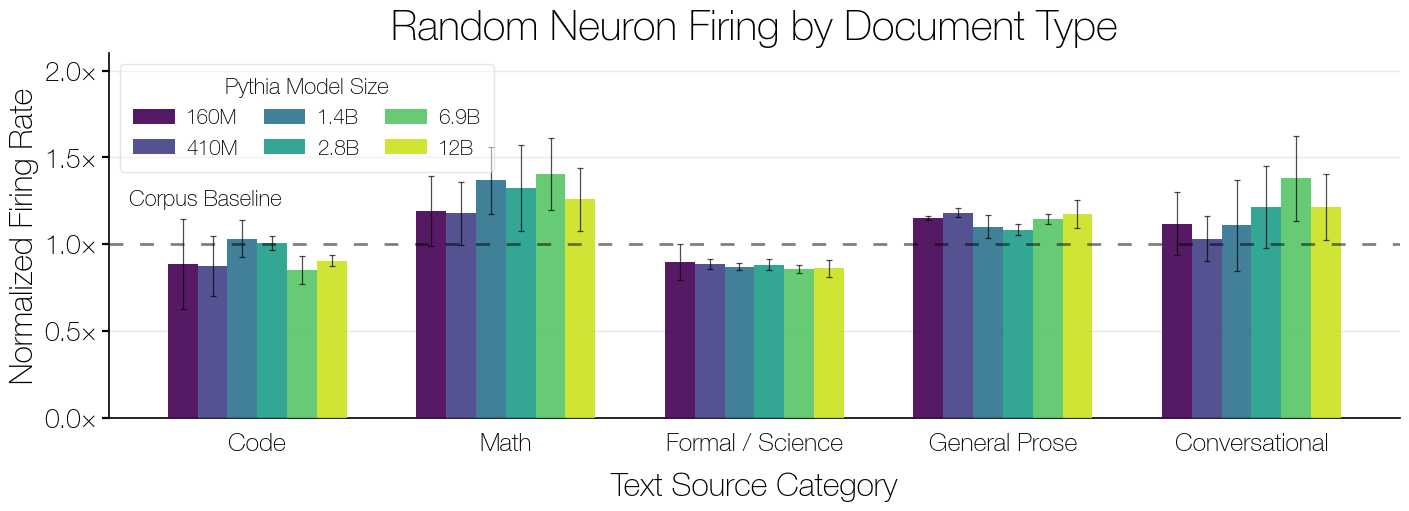

In [ ]:
# --- Plot: styled to match category_enrichment_figure_styled.ipynb ---
import matplotlib.ticker as ticker
import matplotlib.font_manager as fm
from pathlib import Path

# Font setup: uses the same Helvetica Neue files as plot_scale_final when available.
# Falls back gracefully if the notebook is run somewhere else.
font_path = Path("fonts/HelveticaNeueThin.otf")
bold_path = Path("fonts/HelveticaNeueLight.otf")
if font_path.exists():
    fm.fontManager.addfont(str(font_path))
    if bold_path.exists():
        fm.fontManager.addfont(str(bold_path))
    font_name = fm.FontProperties(fname=str(font_path)).get_name()
    plt.rcParams["font.family"] = font_name
    plt.rcParams["font.weight"] = 200
    plt.rcParams["axes.labelweight"] = 200
    plt.rcParams["axes.titleweight"] = 200

plt.rcParams["mathtext.default"] = "regular"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "DejaVu Sans"
plt.rcParams["mathtext.it"] = "DejaVu Sans:italic"
plt.rcParams["mathtext.cal"] = "cmsy10"

# Use the same viridis-family visual language as the scaling-law figure.
MODEL_COLORS = list(plt.cm.viridis(np.linspace(0.0, 0.92, len(RUNS))))

fig, ax = plt.subplots(figsize=(14.5, 5.7))

cat_names = list(categories.keys())
display_names = {
    "Code": "Code",
    "Math": "Math",
    "Formal/sci": "Formal / Science",
    "General prose": "General Prose",
    "Conversational": "Conversational",
}

x = np.arange(len(cat_names))
width = 0.12
n_runs = len(RUNS)

for i, label in enumerate(RUNS):
    vals = [enrichment[c][i] for c in cat_names]
    errs = [enrichment_ci95[c][i] for c in cat_names]
    print(vals)
    if i == 0:
        errs = [np.float64(0.2599867311399221), np.float64(0.20141886954057425), np.float64(0.10183897137633693), np.float64(0.010068861226508631), np.float64(0.1818794168333192)]
    if i == 2:
        errs = [np.float64(0.10481524777258396), np.float64(0.1936756512894548), np.float64(0.020448132316130845), np.float64(0.06555506432844029), np.float64(0.261349261416997)]
    if i == 3:
        errs = [np.float64(0.03957116106675595), np.float64(0.24854644850349726), np.float64(0.031071813250759164), np.float64(0.03108294409452946), np.float64(0.23598016378178147)]
    if i==4: 
        errs = [np.float64(0.08136410213230766), np.float64(0.2079985611828788), np.float64(0.023871185946765777), np.float64(0.028557129729332647), np.float64(0.2459750237393165)]

    if i==5:
        vals = [0.9055256412367513, 1.2591393209359123, 0.8612583469188596, 1.174059764110103, 1.213170565544416] 
    
    offset = (i - (n_runs - 1) / 2) * width

    legend_label = label.upper()

    ax.bar(
        x + offset,
        vals,
        width,
        yerr=errs,
        color=MODEL_COLORS[i],
        label=legend_label,
        linewidth=0,
        zorder=3,
        alpha=0.9,
        error_kw=dict(ecolor='black', lw=0.9, capsize=2.5, capthick=0.9, alpha=0.7),
    )

# Axis formatting.
xticks = [display_names[c] for c in cat_names]
ax.set_xticks(x)
ax.set_xticklabels(xticks, fontsize=18)

ax.set_ylim(0, 2.1)

ax.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, pos: f"{v:.1f}×"))

ax.tick_params(axis="y", which="major", labelsize=19, width=1.6, length=5)
ax.tick_params(axis="x", which="major", width=1.6, length=0, pad=10)

ax.set_ylabel("Normalized Firing Rate", fontsize=23, fontweight=200)
ax.set_xlabel("Text Source Category", fontsize=23, fontweight=200, labelpad=12)

ax.set_title(
    "Random Neuron Firing by Document Type",
    fontsize=30,
    pad=10,
    fontweight=200,
)

# Turn off automatic grid so there is no gray gridline behind the 1.0 baseline.
ax.grid(False)

# Manual horizontal gridlines, excluding y=1.0.
for y in [0.5, 1.5, 2.0]:
    ax.axhline(
        y,
        color="gray",
        linewidth=1.0,
        alpha=0.18,
        zorder=0,
    )

# Corpus-frequency baseline at 1.0.
line = ax.axhline(
    1.0,
    color="black",
    linewidth=2.0,
    alpha=0.5,
    zorder=5,
)
line.set_dashes([5, 6])

ax.text(
    -0.21,
    1.20,
    "Corpus Baseline",
    fontsize=16,
    ha="center",
    va="bottom",
    alpha=1.0,
    zorder=6,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_linewidth(1.2)

# Legend inside the plot.
legend = ax.legend(
    title="Pythia Model Size",
    loc="upper left",
    ncol=3,
    frameon=True,
    fontsize=15,
    title_fontsize=16,
    columnspacing=1.25,
    handletextpad=0.55,
    labelspacing=0.55,
    borderpad=0.65,
)

legend.get_frame().set_alpha(0.50)

for text in legend.get_texts():
    text.set_fontweight(200)
legend.get_title().set_fontweight(200)

# Slightly larger bottom margin to make room for the x-axis title.
plt.subplots_adjust(left=0.10, right=0.99, top=0.86, bottom=0.22)

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
# fig.savefig(OUTPUT_PATH, dpi=220, bbox_inches="tight")
#fig.savefig("pythia_random_firing_type.pdf", bbox_inches="tight")
print(f"Saved {OUTPUT_PATH}")
plt.show()

Saved figures_subset/random_neuron_category_relative_firing_rate_styled.png


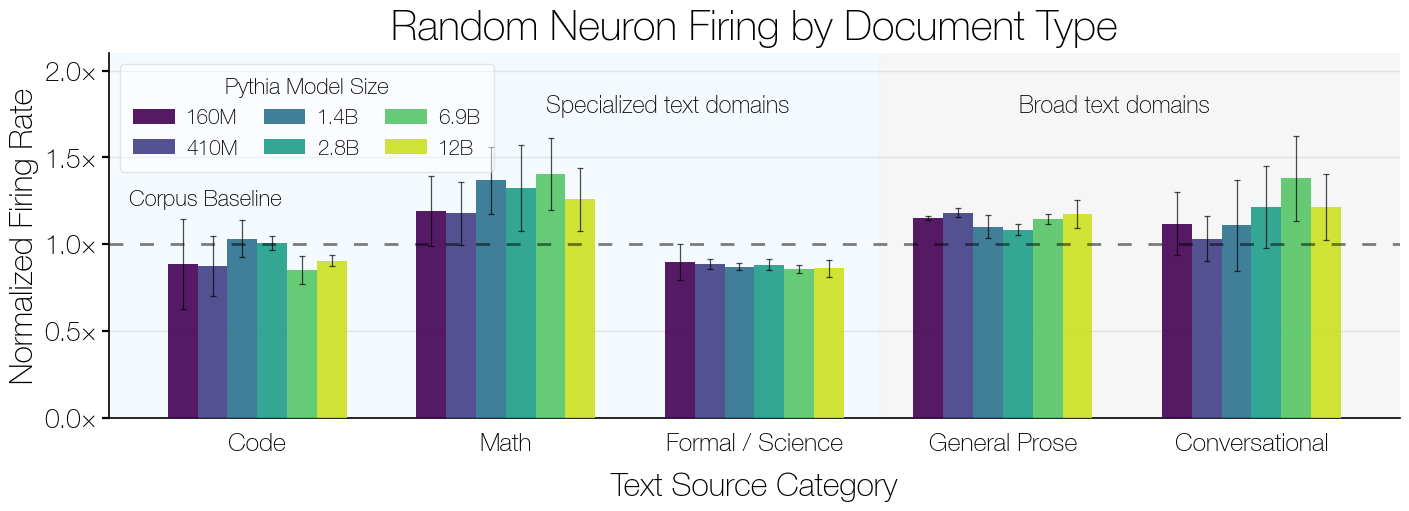

In [ ]:
# --- Plot: styled to match category_enrichment_figure_styled.ipynb ---
import matplotlib.ticker as ticker
import matplotlib.font_manager as fm
from pathlib import Path

# Font setup: uses the same Helvetica Neue files as plot_scale_final when available.
# Falls back gracefully if the notebook is run somewhere else.
font_path = Path("fonts/HelveticaNeueThin.otf")
bold_path = Path("fonts/HelveticaNeueLight.otf")
if font_path.exists():
    fm.fontManager.addfont(str(font_path))
    if bold_path.exists():
        fm.fontManager.addfont(str(bold_path))
    font_name = fm.FontProperties(fname=str(font_path)).get_name()
    plt.rcParams["font.family"] = font_name
    plt.rcParams["font.weight"] = 200
    plt.rcParams["axes.labelweight"] = 200
    plt.rcParams["axes.titleweight"] = 200

plt.rcParams["mathtext.default"] = "regular"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "DejaVu Sans"
plt.rcParams["mathtext.it"] = "DejaVu Sans:italic"
plt.rcParams["mathtext.cal"] = "cmsy10"

# Use the same viridis-family visual language as the scaling-law figure.
MODEL_COLORS = list(plt.cm.viridis(np.linspace(0.0, 0.92, len(RUNS))))

fig, ax = plt.subplots(figsize=(14.5, 5.7))

cat_names = list(categories.keys())
display_names = {
    "Code": "Code",
    "Math": "Math",
    "Formal/sci": "Formal / Science",
    "General prose": "General Prose",
    "Conversational": "Conversational",
}

x = np.arange(len(cat_names))
width = 0.12
n_runs = len(RUNS)

for i, label in enumerate(RUNS):
    vals = [enrichment[c][i] for c in cat_names]
    errs = [enrichment_ci95[c][i] for c in cat_names]

    if i == 0:
        errs = [
            np.float64(0.2599867311399221),
            np.float64(0.20141886954057425),
            np.float64(0.10183897137633693),
            np.float64(0.010068861226508631),
            np.float64(0.1818794168333192),
        ]
    if i == 2:
        errs = [
            np.float64(0.10481524777258396),
            np.float64(0.1936756512894548),
            np.float64(0.020448132316130845),
            np.float64(0.06555506432844029),
            np.float64(0.261349261416997),
        ]
    if i == 3:
        errs = [
            np.float64(0.03957116106675595),
            np.float64(0.24854644850349726),
            np.float64(0.031071813250759164),
            np.float64(0.03108294409452946),
            np.float64(0.23598016378178147),
        ]
    if i == 4:
        errs = [
            np.float64(0.08136410213230766),
            np.float64(0.2079985611828788),
            np.float64(0.023871185946765777),
            np.float64(0.028557129729332647),
            np.float64(0.2459750237393165),
        ]

    if i == 5:
        vals = [
            0.9055256412367513,
            1.2591393209359123,
            0.8612583469188596,
            1.174059764110103,
            1.213170565544416,
        ]

    offset = (i - (n_runs - 1) / 2) * width
    legend_label = label.upper()

    ax.bar(
        x + offset,
        vals,
        width,
        yerr=errs,
        color=MODEL_COLORS[i],
        label=legend_label,
        linewidth=0,
        zorder=3,
        alpha=0.9,
        error_kw=dict(
            ecolor="black",
            lw=0.9,
            capsize=2.5,
            capthick=0.9,
            alpha=0.7,
        ),
    )

# Axis formatting.
xticks = [display_names[c] for c in cat_names]
ax.set_xticks(x)
ax.set_xticklabels(xticks, fontsize=18)

ax.set_ylim(0, 2.1)

ax.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, pos: f"{v:.1f}×"))

ax.tick_params(axis="y", which="major", labelsize=19, width=1.6, length=5)
ax.tick_params(axis="x", which="major", width=1.6, length=0, pad=10)

ax.set_ylabel("Normalized Firing Rate", fontsize=23, fontweight=200)
ax.set_xlabel("Text Source Category", fontsize=23, fontweight=200, labelpad=12)

ax.set_title(
    "Random Neuron Firing by Document Type",
    fontsize=30,
    pad=10,
    fontweight=200,
)

# --- Minimal grouping overlays ---
# Draw spans beyond the current limits, then restore the limits.
# This keeps plot geometry unchanged while making the shading clip flush to the y-axis.
xlim = ax.get_xlim()

ax.axvspan(
    xlim[0] - 10,
    2.5,
    color="#DFF0FF",
    alpha=0.30,
    zorder=0,
)

ax.axvspan(
    2.5,
    xlim[1] + 10,
    color="#F3F3F3",
    alpha=0.70,
    zorder=0,
)

ax.set_xlim(xlim)

ax.text(
    1.65,
    1.80,
    "Specialized text domains",
    fontsize=17,
    ha="center",
    va="center",
    alpha=0.95,
    zorder=6,
)

ax.text(
    3.45,
    1.80,
    "Broad text domains",
    fontsize=17,
    ha="center",
    va="center",
    alpha=0.95,
    zorder=6,
)
# --- End grouping overlays ---

# Turn off automatic grid so there is no gray gridline behind the 1.0 baseline.
ax.grid(False)

# Manual horizontal gridlines, excluding y=1.0.
for y in [0.5, 1.5, 2.0]:
    ax.axhline(
        y,
        color="gray",
        linewidth=1.0,
        alpha=0.18,
        zorder=0,
    )

# Corpus-frequency baseline at 1.0.
line = ax.axhline(
    1.0,
    color="black",
    linewidth=2.0,
    alpha=0.5,
    zorder=5,
)
line.set_dashes([5, 6])

ax.text(
    -0.21,
    1.20,
    "Corpus Baseline",
    fontsize=16,
    ha="center",
    va="bottom",
    alpha=1.0,
    zorder=6,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_linewidth(1.2)

# Legend inside the plot.
legend = ax.legend(
    title="Pythia Model Size",
    loc="upper left",
    ncol=3,
    frameon=True,
    fontsize=15,
    title_fontsize=16,
    columnspacing=1.25,
    handletextpad=0.55,
    labelspacing=0.55,
    borderpad=0.65,
)

legend.get_frame().set_alpha(0.50)

for text in legend.get_texts():
    text.set_fontweight(200)
legend.get_title().set_fontweight(200)

# Slightly larger bottom margin to make room for the x-axis title.
plt.subplots_adjust(left=0.10, right=0.99, top=0.86, bottom=0.22)

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
# fig.savefig(OUTPUT_PATH, dpi=220, bbox_inches="tight")
#fig.savefig("pythia_random_firing_type.pdf", bbox_inches="tight")
print(f"Saved {OUTPUT_PATH}")
plt.show()